# Heston：模型差异与时间离散化

Heston 使用 log-Euler 股价与 full-truncation Euler 方差，保留 raw variance 状态，在漂移/扩散中使用正部。初始/长期方差=0.04 对应 20% 波动率；xi 是波动率的波动率。

使用已构建扩展的项目 Python 内核。所有价格方法可使用 Heston；解析 GBM 控制、连续 bridge 和当前 Greeks 要求 GBM。采样置信区间不包含 Heston 离散化偏差。

module: 0.1.0
engine: McEngine(paths=12000, seed=42, antithetic=true, parallel=true)
GBM: GbmModel(spot=100, r=0.03, q=0.01, sigma=0.2, t=1, steps=252)
Heston: {'spot': 100.0, 'r': 0.03, 'q': 0.01, 't': 1.0, 'steps': 252, 'v0': 0.04, 'kappa': 1.5, 'theta': 0.04, 'xi': 0.4, 'rho': -0.7}


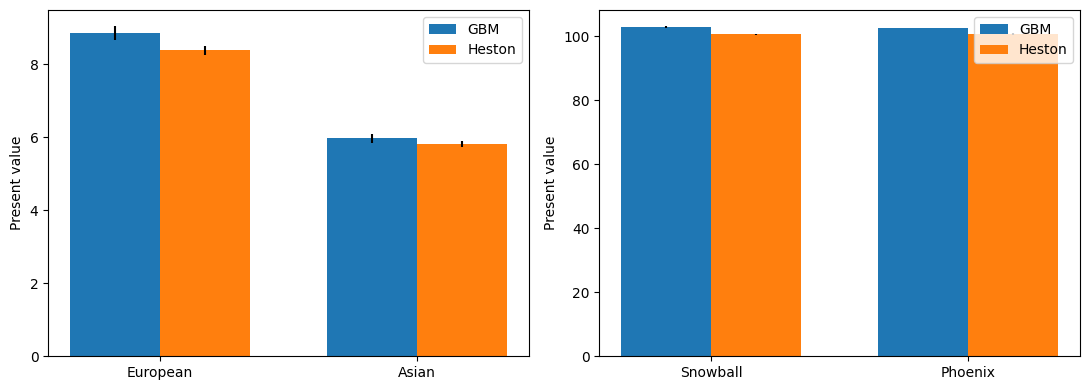

In [1]:
import math
from time import perf_counter
import numpy as np
import matplotlib.pyplot as plt
import fuzzy_enigma as fe

PATHS, SEED = 12_000, 42
engine = fe.McEngine(paths=PATHS, seed=SEED, antithetic=True, parallel=True)
records = []

def timed(label, call, **parameters):
    start = perf_counter()
    result = call()
    record = dict(label=label, price=result.price, std_error=result.std_error,
                  samples=result.samples, ci95=result.confidence_95(),
                  elapsed_s=perf_counter()-start, paths=PATHS, seed=SEED,
                  parameters=parameters)
    records.append(record)
    return result

print('module:', fe.__version__)
print('engine:', engine)

common = dict(spot=100.0, r=0.03, q=0.01, t=1.0, steps=252)
heston_params = {**common, 'v0': 0.04, 'kappa': 1.5, 'theta': 0.04, 'xi': 0.4, 'rho': -0.7}
gbm = fe.GbmModel(**common, sigma=0.2)
heston = fe.HestonModel(**heston_params)
dates = [63, 126, 189, 252]
print('GBM:', gbm)
print('Heston:', heston_params)
comparison = {}
for name, model in [('GBM', gbm), ('Heston', heston)]:
    comparison[name] = [
        timed(name+' European', lambda: engine.price_european(model, 'call', 100.0), model=repr(model), strike=100.0),
        timed(name+' Asian', lambda: engine.price_asian_scheduled(model, 'call', 100.0, dates), model=repr(model), strike=100.0, dates=dates),
        timed(name+' Snowball', lambda: engine.price_snowball(model, 100.0, 100.0, 0.12, 70.0, 103.0, dates), model=repr(model), reference_spot=100.0, ki=70.0, ko=103.0, coupon_rate=0.12, dates=dates),
        timed(name+' Phoenix', lambda: engine.price_phoenix(model, 100.0, 100.0, 2.0, 80.0, 60.0, 105.0, dates, dates, memory=True), model=repr(model), reference_spot=100.0, coupon_cash=2.0, coupon_barrier=80.0, ki=60.0, ko=105.0, memory=True, dates=dates),
    ]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for offset, (name, rs) in enumerate(comparison.items()):
    for ax, indices, labels in [(axes[0], [0, 1], ['European', 'Asian']), (axes[1], [2, 3], ['Snowball', 'Phoenix'])]:
        selected = [rs[i] for i in indices]
        ax.bar(np.arange(2)+0.35*offset, [r.price for r in selected], width=0.35,
               yerr=[1.96*r.std_error for r in selected], label=name)
        ax.set_xticks(np.arange(2)+0.175, labels); ax.set_ylabel('Present value'); ax.legend()
fig.tight_layout(); plt.show()


## 不同步数与半解析基准

下面使用 Rust 测试中的独立特征函数积分参考值 `8.34086669608562`，对应本例 S=K=100、r=0.03、q=0.01、T=1、v0=theta=0.04、kappa=1.5、xi=0.4、rho=-0.7。[Heston 半解析公式](https://doi.org/10.1093/rfs/6.2.327)

同一 seed 在不同网格上只表示可复现；改变步数会改变随机输入维度。用误差条同时观察采样不确定性，不能要求每一次加密网格价格都单调接近基准。

16 price 8.458045070053718 gap 0.11717837396809827 SE 0.06687970743974389
64 price 8.430497776676983 gap 0.0896310805913636 SE 0.06326798938875865
256 price 8.372409276672123 gap 0.03154258058650328 SE 0.06083753072726466
512 price 8.297185859852066 gap -0.04368083623355368 SE 0.06130759327722207


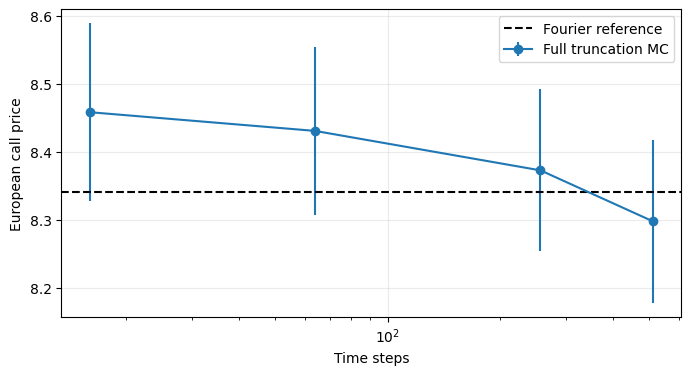

In [2]:
reference = 8.34086669608562
grids = [16, 64, 256, 512]
convergence = []
for steps in grids:
    params = {**heston_params, 'steps': steps}
    m = fe.HestonModel(**params)
    result = timed('Heston grid convergence', lambda: engine.price_european(m, 'call', 100.0),
                   **params, strike=100.0)
    convergence.append(result)
    print(steps, 'price', result.price, 'gap', result.price-reference, 'SE', result.std_error)
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(grids, [r.price for r in convergence], yerr=[1.96*r.std_error for r in convergence], fmt='o-', label='Full truncation MC')
ax.axhline(reference, color='black', linestyle='--', label='Fourier reference')
ax.set(xscale='log', xlabel='Time steps', ylabel='European call price')
ax.grid(alpha=0.25); ax.legend(); plt.show()


## 常方差极限和模型类型检查

xi=0 且 v0=theta 时，Heston 的经济模型退化为常波动率 GBM。两种实现每步抽取的噪声数量不同，因此用价格与标准误作统计比较；Rust 测试另外用匹配的股价噪声逐步核对路径。

In [3]:
constant_params = {**heston_params, 'xi': 0.0}
constant = fe.HestonModel(**constant_params)
constant_result = timed('Heston constant variance', lambda: engine.price_european(constant, 'call', 100.0),
                        **constant_params, strike=100.0)
gbm_result = comparison['GBM'][0]
print('Constant variance Heston:', constant_result)
print('GBM:', gbm_result)
assert abs(constant_result.price-gbm_result.price) < 5*math.hypot(constant_result.std_error, gbm_result.std_error)
try:
    engine.greeks_european(heston, 'call', 100.0)
except ValueError as exc:
    print('Expected model restriction:', exc)
else:
    raise AssertionError('Heston must not silently use GBM Greeks')


Constant variance Heston: PriceResult(price=9.008937, std_error=0.095858, samples=6000, ci95=[8.821059, 9.196815])
GBM: PriceResult(price=8.845729, std_error=0.093693, samples=6000, ci95=[8.662094, 9.029365])
Expected model restriction: invalid parameter `model`: this method requires GbmModel


In [4]:
for row in records:
    print(f"{row['label']:<28} price={row['price']:9.5f} SE={row['std_error']:.5f} "
          f"elapsed={row['elapsed_s']:.3f}s paths={row['paths']} seed={row['seed']} "
          f"params={row['parameters']}")


GBM European                 price=  8.84573 SE=0.09369 elapsed=0.007s paths=12000 seed=42 params={'model': 'GbmModel(spot=100, r=0.03, q=0.01, sigma=0.2, t=1, steps=252)', 'strike': 100.0}
GBM Asian                    price=  5.96666 SE=0.06153 elapsed=0.007s paths=12000 seed=42 params={'model': 'GbmModel(spot=100, r=0.03, q=0.01, sigma=0.2, t=1, steps=252)', 'strike': 100.0, 'dates': [63, 126, 189, 252]}
GBM Snowball                 price=102.79685 SE=0.08999 elapsed=0.008s paths=12000 seed=42 params={'model': 'GbmModel(spot=100, r=0.03, q=0.01, sigma=0.2, t=1, steps=252)', 'reference_spot': 100.0, 'ki': 70.0, 'ko': 103.0, 'coupon_rate': 0.12, 'dates': [63, 126, 189, 252]}
GBM Phoenix                  price=102.50928 SE=0.04014 elapsed=0.007s paths=12000 seed=42 params={'model': 'GbmModel(spot=100, r=0.03, q=0.01, sigma=0.2, t=1, steps=252)', 'reference_spot': 100.0, 'coupon_cash': 2.0, 'coupon_barrier': 80.0, 'ki': 60.0, 'ko': 105.0, 'memory': True, 'dates': [63, 126, 189, 252]}
Hes